In [14]:
import yfinance as yf


In [15]:
d=yf.download("AAPL",start="2025-09-29",end="2026-03-29")
d


/tmp/ipykernel_26382/2221650730.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d=yf.download("AAPL",start="2025-09-29",end="2026-03-29")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-09-29,253.945969,254.514892,252.528672,254.075726,40127700
2025-09-30,254.145599,255.433139,252.628487,254.375158,37704300
2025-10-01,254.964035,258.297693,254.445020,254.554811,48713900
2025-10-02,256.640839,257.688829,253.666497,256.091867,42630200
2025-10-03,257.529144,258.746825,253.466895,254.185526,49155600
...,...,...,...,...,...
2026-03-23,251.490005,254.600006,250.279999,253.970001,40546100
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300


In [16]:
d.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-09-29,253.945969,254.514892,252.528672,254.075726,40127700
2025-09-30,254.145599,255.433139,252.628487,254.375158,37704300
2025-10-01,254.964035,258.297693,254.445020,254.554811,48713900
2025-10-02,256.640839,257.688829,253.666497,256.091867,42630200
2025-10-03,257.529144,258.746825,253.466895,254.185526,49155600


In [ ]:
aa=yf.Ticker("AAPL")
print(aa.info['currentPrice'])

266.17


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [17]:
cl=d['Close']

In [ ]:
from statsmodels.tsa.stattools import adfuller


In [19]:
r=adfuller(cl)
print(cl)

Ticker            AAPL
Date                  
2025-09-29  253.945969
2025-09-30  254.145599
2025-10-01  254.964035
2025-10-02  256.640839
2025-10-03  257.529144
...                ...
2026-03-23  251.490005
2026-03-24  251.639999
2026-03-25  252.619995
2026-03-26  252.889999
2026-03-27  248.800003

[125 rows x 1 columns]


In [21]:
cld=cl.diff().dropna().head()


In [23]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(cl,order=(2,1,2))
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  125
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -327.951
Date:                Wed, 22 Apr 2026   AIC                            665.902
Time:                        11:14:15   BIC                            680.003
Sample:                             0   HQIC                           671.630
                                - 125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2570      3.168     -0.081      0.935      -6.467       5.953
ar.L2         -0.0475      1.428     -0.033      0.973      -2.847       2.752
ma.L1          0.4180      3.179      0.131      0.8

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [26]:

f=model_fit.forecast(steps=5)
print(f)



125    248.203263
126    248.602386
127    248.528196
128    248.528285
129    248.531789
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


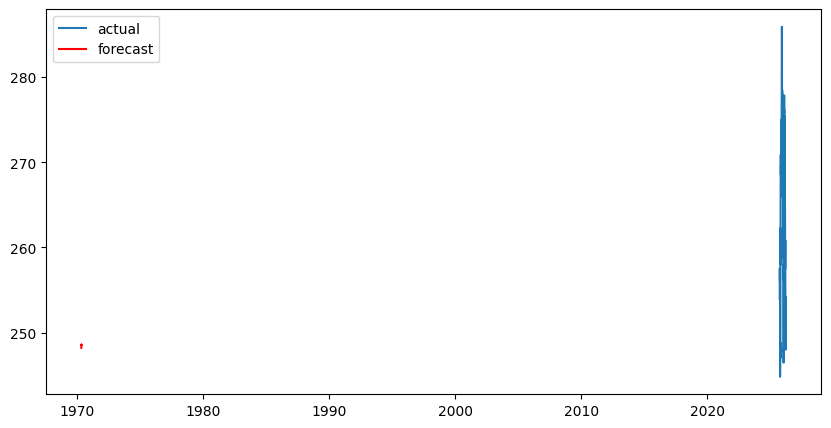

In [28]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(cl,label="actual")
plt.plot(f,label="forecast",color="red")
plt.legend()
plt.show()